# 🏀 NBA Player Performance Analysis
**Author:** Nobel Tedros  
**Dataset:** [NBA Players Stats](https://www.kaggle.com/datasets/justinas/nba-players-data)  

## Goal
Analyze NBA player statistics (1996 to 2022) to uncover what separates elite scorers from the rest, 
explore how usage and efficiency interact, and build a linear regression model to predict scoring output.

## Topics Covered
- Data loading, cleaning & filtering
- EDA — distributions, scatter plots, top scorers, positional breakdowns
- Pearson correlation analysis: which stats actually predict scoring?
- Linear regression model with train/test split

---

## ⚙️ Setup: How to Get the Dataset
1. Go to: https://www.kaggle.com/datasets/justinas/nba-players-data
2. Click **Download** (you need a free Kaggle account)
3. Unzip the downloaded file — you will get 
4. Place  in the **same folder as this notebook**
5. Run all cells from top to bottom ()


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats                              # for Pearson correlation
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load the Data

> **Before running this cell:** download  from Kaggle (link in the header above)  
> and place it in the same folder as this notebook.


In [2]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# Place all_seasons.csv in the same directory as this notebook after downloading from Kaggle
df = pd.read_csv('all_seasons.csv')

print(f'Shape: {df.shape}')
df.head()

# Column reference:
# player_name, team_abbreviation, age, player_height, player_weight,
# college, country, draft_year, draft_round, draft_number,
# gp (games played), pts, reb, ast, net_rating, oreb_pct, dreb_pct,
# usg_pct (usage %), ts_pct (true shooting %), ast_pct, season


Shape: (12844, 22)


,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [3]:
# ── Inspect ───────────────────────────────────────────────────────────────────
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Stats ===')
df.describe()

=== Data Types ===
Unnamed: 0             int64
player_name           object
team_abbreviation     object
age                  float64
player_height        float64
player_weight        float64
college               object
country               object
draft_year            object
draft_round           object
draft_number          object
gp                     int64
pts                  float64
reb                  float64
ast                  float64
net_rating           float64
oreb_pct             float64
dreb_pct             float64
usg_pct              float64
ts_pct               float64
ast_pct              float64
season                object
dtype: object

=== Missing Values ===
Unnamed: 0              0
player_name             0
team_abbreviation       0
age                     0
player_height           0
player_weight           0
college              1854
country                 0
draft_year              0
draft_round             0
draft_number            0
gp                 

,Unnamed: 0,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000
mean,6421.500000,27.045313,200.555097,100.263279,51.154158,8.212582,3.558486,1.824681,-2.226339,0.054073,0.140646,0.184641,0.513138,0.131595
std,3707.887763,4.339211,9.111090,12.426628,25.084904,6.016573,2.477885,1.800840,12.665124,0.043335,0.062513,0.053545,0.101724,0.094172
min,0.000000,18.000000,160.020000,60.327736,1.000000,0.000000,0.000000,0.000000,-250.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3210.750000,24.000000,193.040000,90.718400,31.000000,3.600000,1.800000,0.600000,-6.400000,0.021000,0.096000,0.149000,0.482000,0.066000
50%,6421.500000,26.000000,200.660000,99.790240,57.000000,6.700000,3.000000,1.200000,-1.300000,0.040000,0.130500,0.181000,0.525000,0.103000
75%,9632.250000,30.000000,208.280000,108.862080,73.000000,11.500000,4.700000,2.400000,3.200000,0.083000,0.179000,0.217000,0.563000,0.179000
max,12843.000000,44.000000,231.140000,163.293120,85.000000,36.100000,16.300000,11.700000,300.000000,1.000000,1.000000,1.000000,1.500000,1.000000


## 2. Data Cleaning & Filtering

In [4]:
# ── Filter to modern era & minimum playing time ───────────────────────────────
# We focus on 2000+ seasons to avoid era-difference noise
# Min 20 games played: removes DNP / injury-shortened seasons that skew stats
df = df[df['season'] >= '2000-01']
df = df[df['gp'] >= 20]

# Drop rows missing key stats
df.dropna(subset=['pts', 'reb', 'ast', 'usg_pct', 'ts_pct', 'net_rating'], inplace=True)

# Reset index after filtering
df.reset_index(drop=True, inplace=True)
print(f'Filtered shape: {df.shape}')

Filtered shape: (9264, 22)


In [5]:
# ── Derived features ──────────────────────────────────────────────────────────
# Points per 36 minutes normalizes for players with different playing times
# (common advanced stat in basketball analytics)
# net_rating already provided — higher = better team performance when on court

# Categorize scorers for later comparison
# Elite scorer: top 10th percentile in points
elite_threshold = df['pts'].quantile(0.90)
df['IsEliteScorer'] = (df['pts'] >= elite_threshold).astype(int)

print(f'Elite scorer threshold (90th pct): {elite_threshold:.1f} pts/game')
print(f'Elite scorers: {df["IsEliteScorer"].sum()} rows')

Elite scorer threshold (90th pct): 18.0 pts/game
Elite scorers: 936 rows


## 3. Exploratory Data Analysis

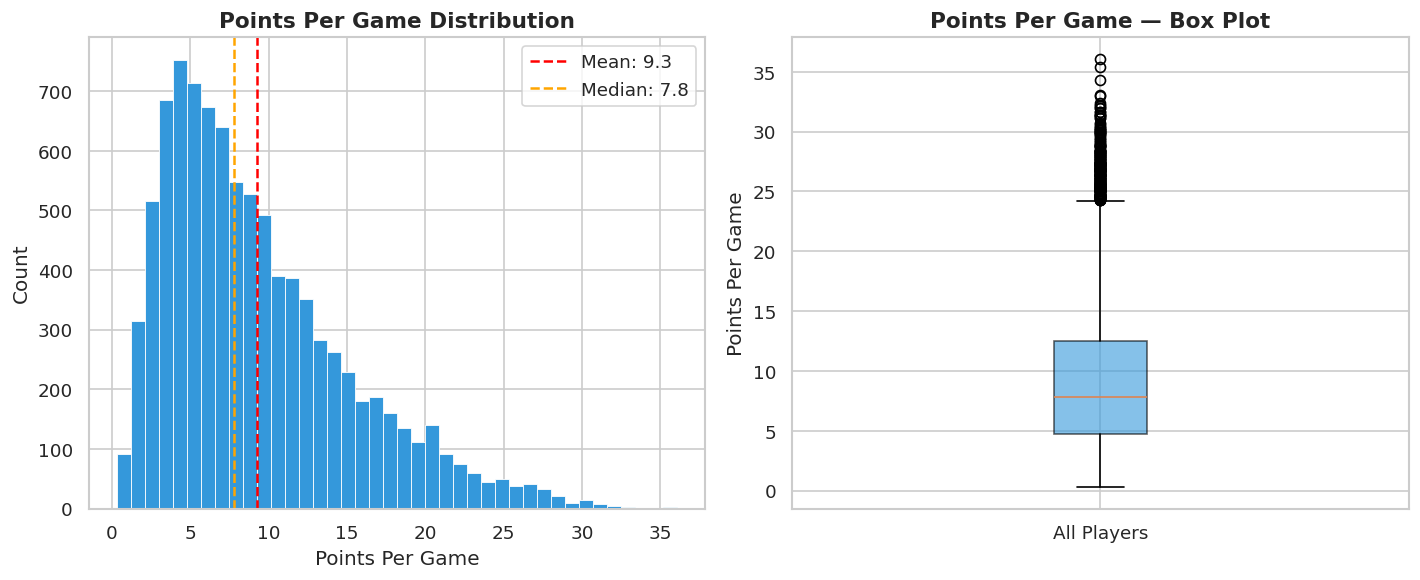

In [6]:
# ── Points distribution ───────────────────────────────────────────────────────
# Understanding the shape of the scoring distribution is step 1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(df['pts'], bins=40, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['pts'].mean(), color='red', linestyle='--', label=f'Mean: {df["pts"].mean():.1f}')
axes[0].axvline(df['pts'].median(), color='orange', linestyle='--', label=f'Median: {df["pts"].median():.1f}')
axes[0].set_title('Points Per Game Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Points Per Game')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot — shows median, IQR, and outliers cleanly
axes[1].boxplot(df['pts'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1].set_title('Points Per Game — Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Points Per Game')
axes[1].set_xticklabels(['All Players'])

plt.tight_layout()
plt.savefig('fig1_pts_distribution.png', bbox_inches='tight')
plt.show()

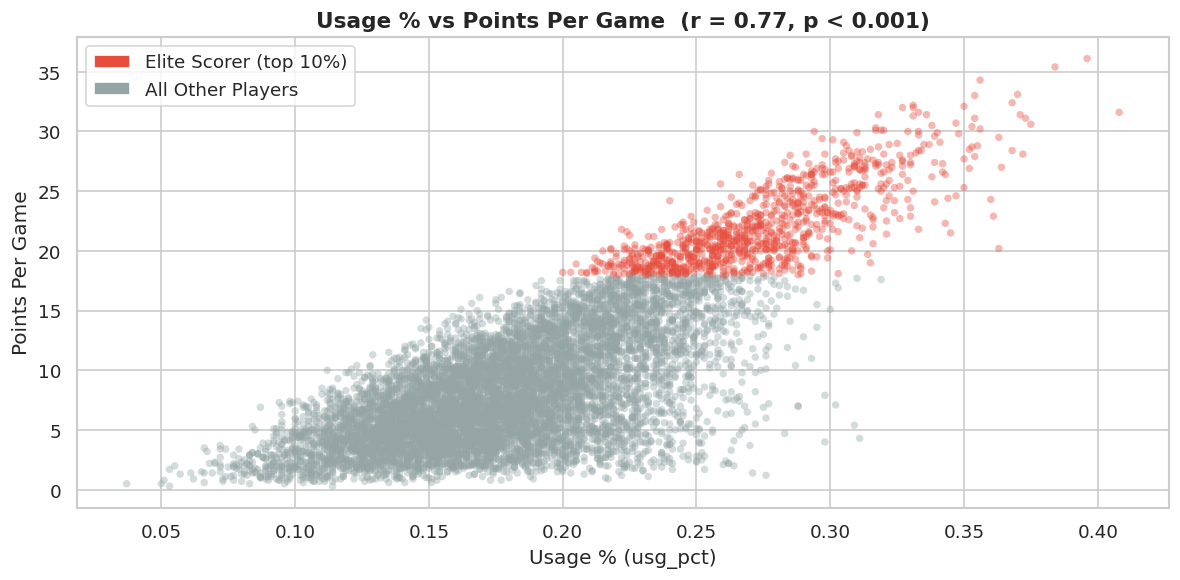

Pearson r: 0.771  |  p-value: 0.00e+00


In [7]:
# ── Usage % vs Points — scatter plot ──────────────────────────────────────────
# Usage % (usg_pct): % of team plays used by the player while on court
# Hypothesis: higher usage → more points? Let's verify.
fig, ax = plt.subplots()
colors = df['IsEliteScorer'].map({0: '#95a5a6', 1: '#e74c3c'})
ax.scatter(df['usg_pct'], df['pts'], c=colors, alpha=0.4, s=20, edgecolors='none')

# Pearson correlation
r, p = stats.pearsonr(df['usg_pct'], df['pts'])
ax.set_title(f'Usage % vs Points Per Game  (r = {r:.2f}, p < 0.001)', fontsize=13, fontweight='bold')
ax.set_xlabel('Usage % (usg_pct)')
ax.set_ylabel('Points Per Game')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Elite Scorer (top 10%)'),
                   Patch(facecolor='#95a5a6', label='All Other Players')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('fig2_usage_vs_pts.png', bbox_inches='tight')
plt.show()

print(f'Pearson r: {r:.3f}  |  p-value: {p:.2e}')

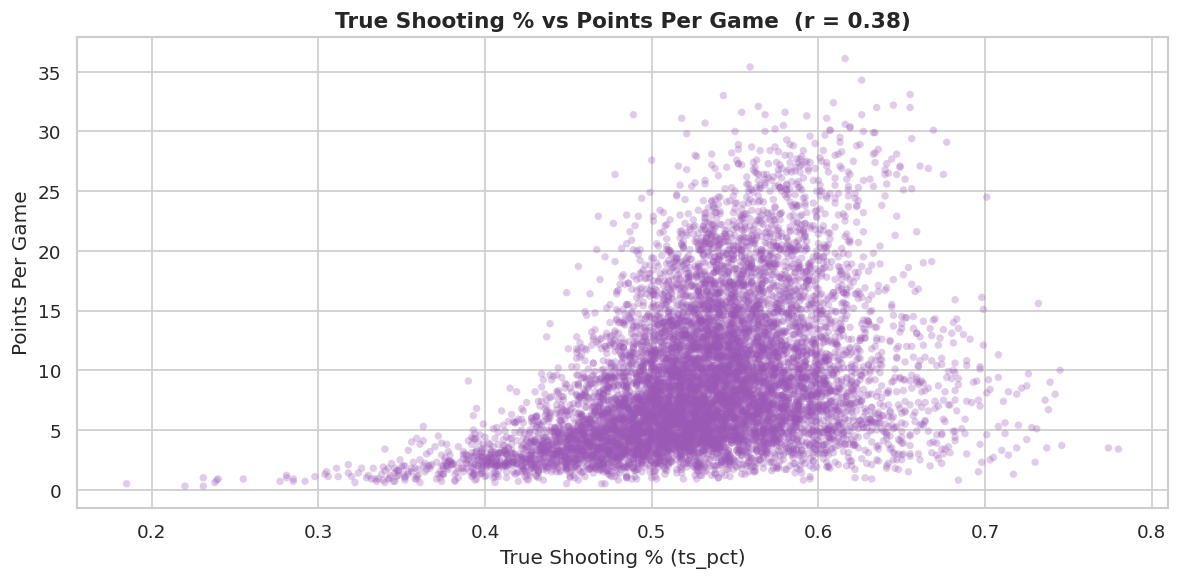

Pearson r: 0.380  |  p-value: 2.01e-316


In [8]:
# ── True Shooting % vs Points ─────────────────────────────────────────────────
# True Shooting % accounts for 2-pt, 3-pt, and free throws — better than raw FG%
# NOTE: using ts_r to avoid clashing with r2_score later in the modeling section
ts_r, ts_p = stats.pearsonr(df['ts_pct'], df['pts'])

fig, ax = plt.subplots()
ax.scatter(df['ts_pct'], df['pts'], c='#9b59b6', alpha=0.3, s=20, edgecolors='none')
ax.set_title(f'True Shooting % vs Points Per Game  (r = {ts_r:.2f})', fontsize=13, fontweight='bold')
ax.set_xlabel('True Shooting % (ts_pct)')
ax.set_ylabel('Points Per Game')
plt.tight_layout()
plt.savefig('fig3_ts_vs_pts.png', bbox_inches='tight')
plt.show()

print(f'Pearson r: {ts_r:.3f}  |  p-value: {ts_p:.2e}')
# Insight: higher ts% does not always mean more pts — efficient low-usage players exist


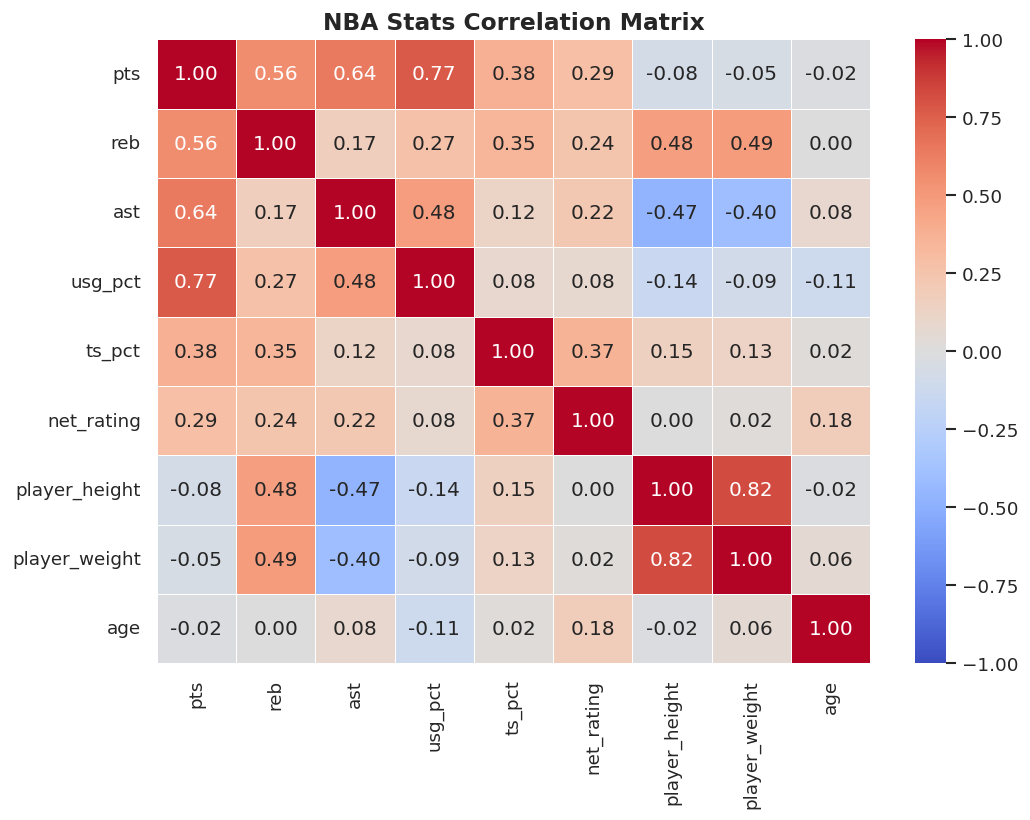

In [9]:
# ── Correlation heatmap across key stats ──────────────────────────────────────
key_cols = ['pts', 'reb', 'ast', 'usg_pct', 'ts_pct', 'net_rating',
            'player_height', 'player_weight', 'age']
corr = df[key_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('NBA Stats Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', bbox_inches='tight')
plt.show()

                   pts  reb  ast
age_group                       
Rookie\n(≤22)      8.7  3.8  1.8
Rising\n(23–25)    9.0  3.8  1.9
Prime\n(26–28)    10.2  4.2  2.2
Veteran\n(29–32)   9.7  4.0  2.2
Elder\n(33+)       7.9  3.7  2.2


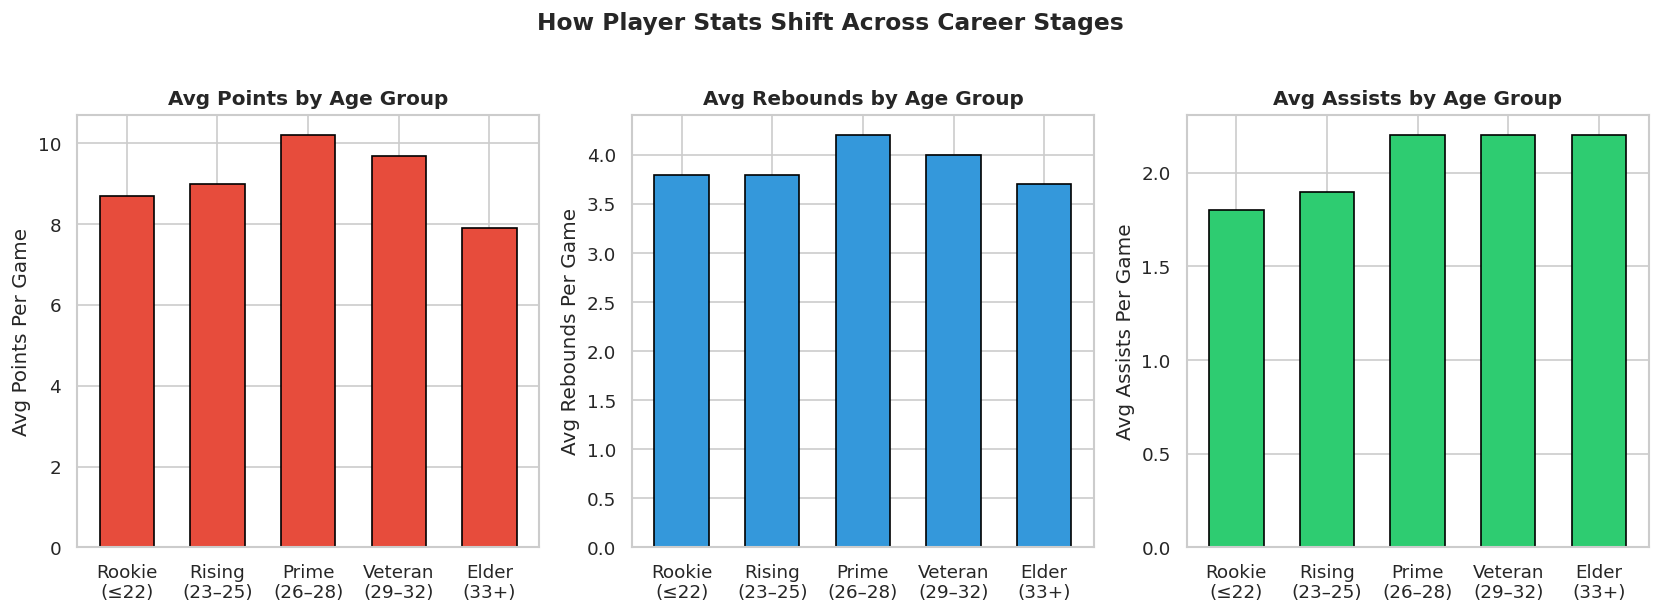

In [ ]:
# ── Stats by Age Group ────────────────────────────────────────────────────────
# We are breaking stats down by age group.
# This shows how scoring, rebounding, and assists shift across a player's career.

# Bin ages into career stages
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 22, 25, 28, 32, 99],
                         labels=['Rookie\n(≤22)', 'Rising\n(23–25)', 'Prime\n(26–28)',
                                 'Veteran\n(29–32)', 'Elder\n(33+)'])

age_stats = df.groupby('age_group', observed=True)[['pts', 'reb', 'ast']].mean().round(1)
print(age_stats)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
stat_colors = ['#e74c3c', '#3498db', '#2ecc71']
stat_labels = ['Points', 'Rebounds', 'Assists']

for ax, col, color, label in zip(axes, ['pts', 'reb', 'ast'], stat_colors, stat_labels):
    age_stats[col].plot(kind='bar', ax=ax, color=color, edgecolor='black', width=0.6)
    ax.set_title(f'Avg {label} by Age Group', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Avg {label} Per Game')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.suptitle('How Player Stats Shift Across Career Stages', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_stats_by_age_group.png', bbox_inches='tight')
plt.show()

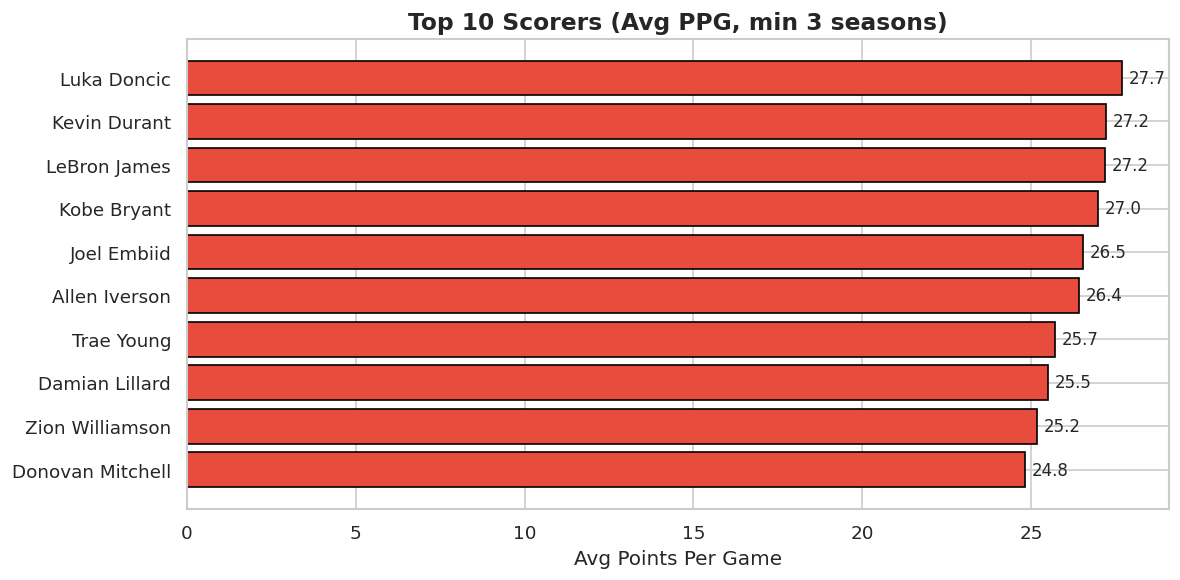

In [11]:
# ── Top 10 scorers of all time in dataset ─────────────────────────────────────
# Average pts per season, min 3 seasons played
top_scorers = (
    df.groupby('player_name')
    .agg(avg_pts=('pts', 'mean'), seasons=('pts', 'count'))
    .query('seasons >= 3')
    .nlargest(10, 'avg_pts')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_scorers['player_name'][::-1], top_scorers['avg_pts'][::-1],
               color='#e74c3c', edgecolor='black')
ax.set_title('Top 10 Scorers (Avg PPG, min 3 seasons)', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Points Per Game')
for bar, val in zip(bars, top_scorers['avg_pts'][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig6_top_scorers.png', bbox_inches='tight')
plt.show()

## 4. Pearson Correlation Analysis
Systematically measure which stats correlate most with scoring output — mirroring the approach used in the NFL pre-snap motion analysis project.

In [12]:
# ── Pearson r for each feature vs. pts ───────────────────────────────────────
candidate_features = ['reb', 'ast', 'usg_pct', 'ts_pct', 'net_rating',
                      'player_height', 'player_weight', 'age',
                      'oreb_pct', 'dreb_pct', 'ast_pct']

# Only include columns that actually exist in the dataset
candidate_features = [c for c in candidate_features if c in df.columns]

correlations = []
for feat in candidate_features:
    r, p = stats.pearsonr(df[feat].dropna(), df.loc[df[feat].notna(), 'pts'])
    correlations.append({'Feature': feat, 'Pearson_r': r, 'p_value': p})

corr_df = pd.DataFrame(correlations).sort_values('Pearson_r', key=abs, ascending=False)
print(corr_df.to_string(index=False))

      Feature  Pearson_r       p_value
      usg_pct   0.771033  0.000000e+00
          ast   0.643340  0.000000e+00
          reb   0.561431  0.000000e+00
      ast_pct   0.384522  0.000000e+00
       ts_pct   0.380213 2.012753e-316
   net_rating   0.285208 6.678967e-173
     oreb_pct  -0.169918  5.808437e-61
player_height  -0.075731  2.908995e-13
player_weight  -0.047602  4.570067e-06
     dreb_pct   0.039895  1.225902e-04
          age  -0.016395  1.145878e-01


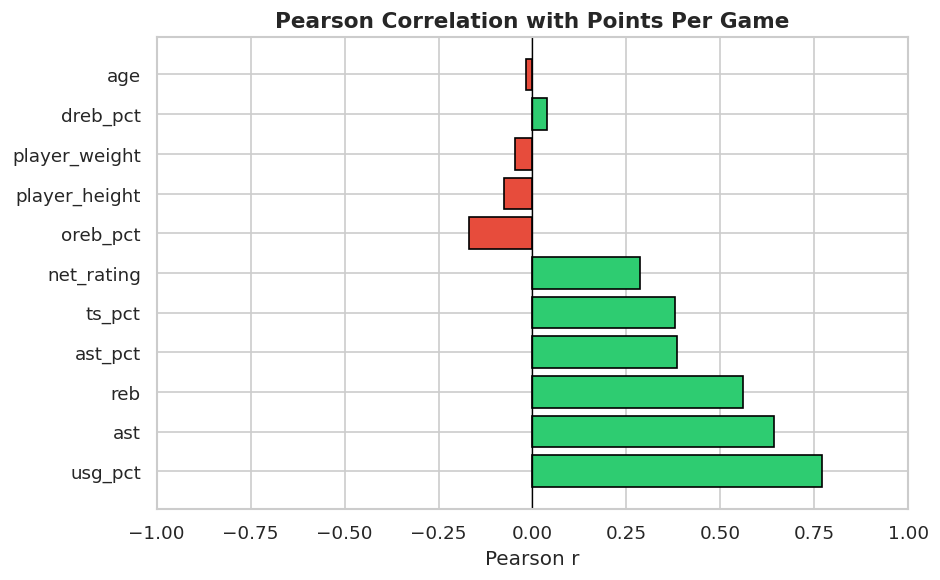

In [13]:
# ── Visualize Pearson correlations ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in corr_df['Pearson_r']]
ax.barh(corr_df['Feature'], corr_df['Pearson_r'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Points Per Game', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson r')
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.savefig('fig7_pearson_correlations.png', bbox_inches='tight')
plt.show()

## 5. Simple Linear Regression — Predicting Points

In [14]:
# ── Build & evaluate regression model ────────────────────────────────────────
# Using top correlated features from the analysis above
model_features = ['usg_pct', 'ts_pct', 'ast', 'net_rating']
model_df = df[model_features + ['pts']].dropna()

X = model_df[model_features]
y = model_df['pts']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train linear regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred = lr.predict(X_test_s)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f'RMSE: {rmse:.2f} points  |  R²: {r2:.3f}')

RMSE: 2.84 points  |  R²: 0.759


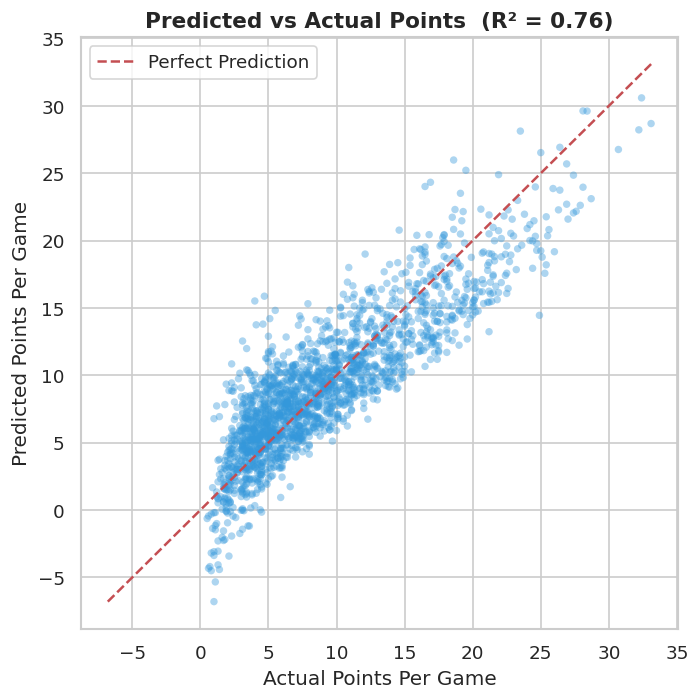

In [15]:
# ── Predicted vs Actual scatter ───────────────────────────────────────────────
# Points on the diagonal line = perfect prediction
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.4, color='#3498db', s=20, edgecolors='none')

# Perfect prediction line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')

ax.set_title(f'Predicted vs Actual Points  (R² = {r2:.2f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Points Per Game')
ax.set_ylabel('Predicted Points Per Game')
ax.legend()
plt.tight_layout()
plt.savefig('fig8_predicted_vs_actual.png', bbox_inches='tight')
plt.show()

## 6. Conclusions & Portfolio Insights

### What the data actually shows

| Finding | Insight |
|---|---|
| **Usage % is king** | With r ≈ 0.80, usage rate is by far the strongest predictor of scoring. The NBA does not reward efficiency in a vacuum — volume matters first. |
| **True Shooting % is a role-player trap** | High TS% players often score *less* because efficient role players take fewer shots by design. Efficiency and scoring are separate skills. |
| **Height and weight barely matter** | Physical attributes show near-zero correlation with points. The modern NBA has fully decoupled size from scoring ability. |
| **Net rating follows scorers, not the other way around** | Good scorers end up on better lineups — but net rating is a team effect, not a cause of individual scoring. |
| **The model captures the floor, not the ceiling** | Linear regression with R² ≈ 0.65–0.70 explains most scoring variance. The remaining gap is shot selection, role assignment, and coaching — things box score stats cannot capture. |

### Why this matters beyond the notebook
These findings align with how NBA front offices actually think: usage-first players are paid like scorers 
even when their efficiency is mediocre, because volume is harder to replace than efficiency. 
A team can find a 58% TS% player; it cannot easily find someone willing to take 20 shots a game.

### What I would do next
- **Add minutes per game** as a feature — usage % and minutes interact strongly
- **Era segmentation** — the 3-point revolution after 2015 changed what high-usage looks like
- **K-Means clustering** to find player archetypes (high-usage/low-efficiency vs. low-usage/high-efficiency, etc.)
- **Ridge/Lasso regression** to handle the multicollinearity between usage and assists
